In [1]:
pip install pandas numpy matplotlib seaborn scikit-learn xgboost lifelines shap streamlit plotly imbalanced-learn


Defaulting to user installation because normal site-packages is not writeable
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
   ---------------------------------------- 0.0/48.9 MB ? eta -:--:--
   --- ------------------------------------ 4.5/48.9 MB 30.5 MB/s eta 0:00:02
   -------------- ------------------------- 17.8/48.9 MB 50.9 MB/s eta 0:00:01
   -------------------------- ------------- 32.2/48.9 MB 58.6 MB/s eta 0:00:01
   -------------------------------------- - 46.9/48.9 MB 62.2 MB/s eta 0:00:01
   ---------------------------------------- 48.9/48.9 MB 54.0 MB/s  0:00:00
  Created wheel for autograd-gamma: filename=autograd_gamma-0.5.0-py3-none-any.whl size=4136 sha256=9fd460cedefce1ce4aa465957cfff4f

In [4]:
# ============================================
# CELL 1: Imports
# ============================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
pd.set_option('display.max_columns', None)

df = pd.read_csv('C:/churn-project/data/telco_churn.csv')

print(df.shape)
df.head()


(7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5]:
# ============================================
# CELL 3: Check data types & weirdness
# ============================================
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
print("Blanks in TotalCharges:", df['TotalCharges'].isnull().sum())


Blanks in TotalCharges: 11


In [6]:
# ============================================
# CELL 4: Fix missing values & drop ID
# ============================================
# These 11 customers have tenure = 0 (brand new customers, never billed)
print(df[df['TotalCharges'].isnull()][['tenure', 'MonthlyCharges', 'Churn']])


      tenure  MonthlyCharges Churn
488        0           52.55    No
753        0           20.25    No
936        0           80.85    No
1082       0           25.75    No
1340       0           56.05    No
3331       0           19.85    No
3826       0           25.35    No
4380       0           20.00    No
5218       0           19.70    No
6670       0           73.35    No
6754       0           61.90    No


In [7]:
df = df.dropna(subset=['TotalCharges'])
df = df.drop('customerID', axis=1)
df.reset_index(drop=True, inplace=True)
print("Final shape:", df.shape)   # (7032, 20)


Final shape: (7032, 20)


In [8]:
# ============================================
# CELL 5: Class balance
# ============================================
print(df['Churn'].value_counts())
print(f"\nChurn rate: {df['Churn'].value_counts(normalize=True)['Yes']:.1%}")


Churn
No     5163
Yes    1869
Name: count, dtype: int64

Churn rate: 26.6%


In [10]:
import os
os.makedirs('C:/churn-project/images', exist_ok=True)
print("Images folder ready!")


Images folder ready!


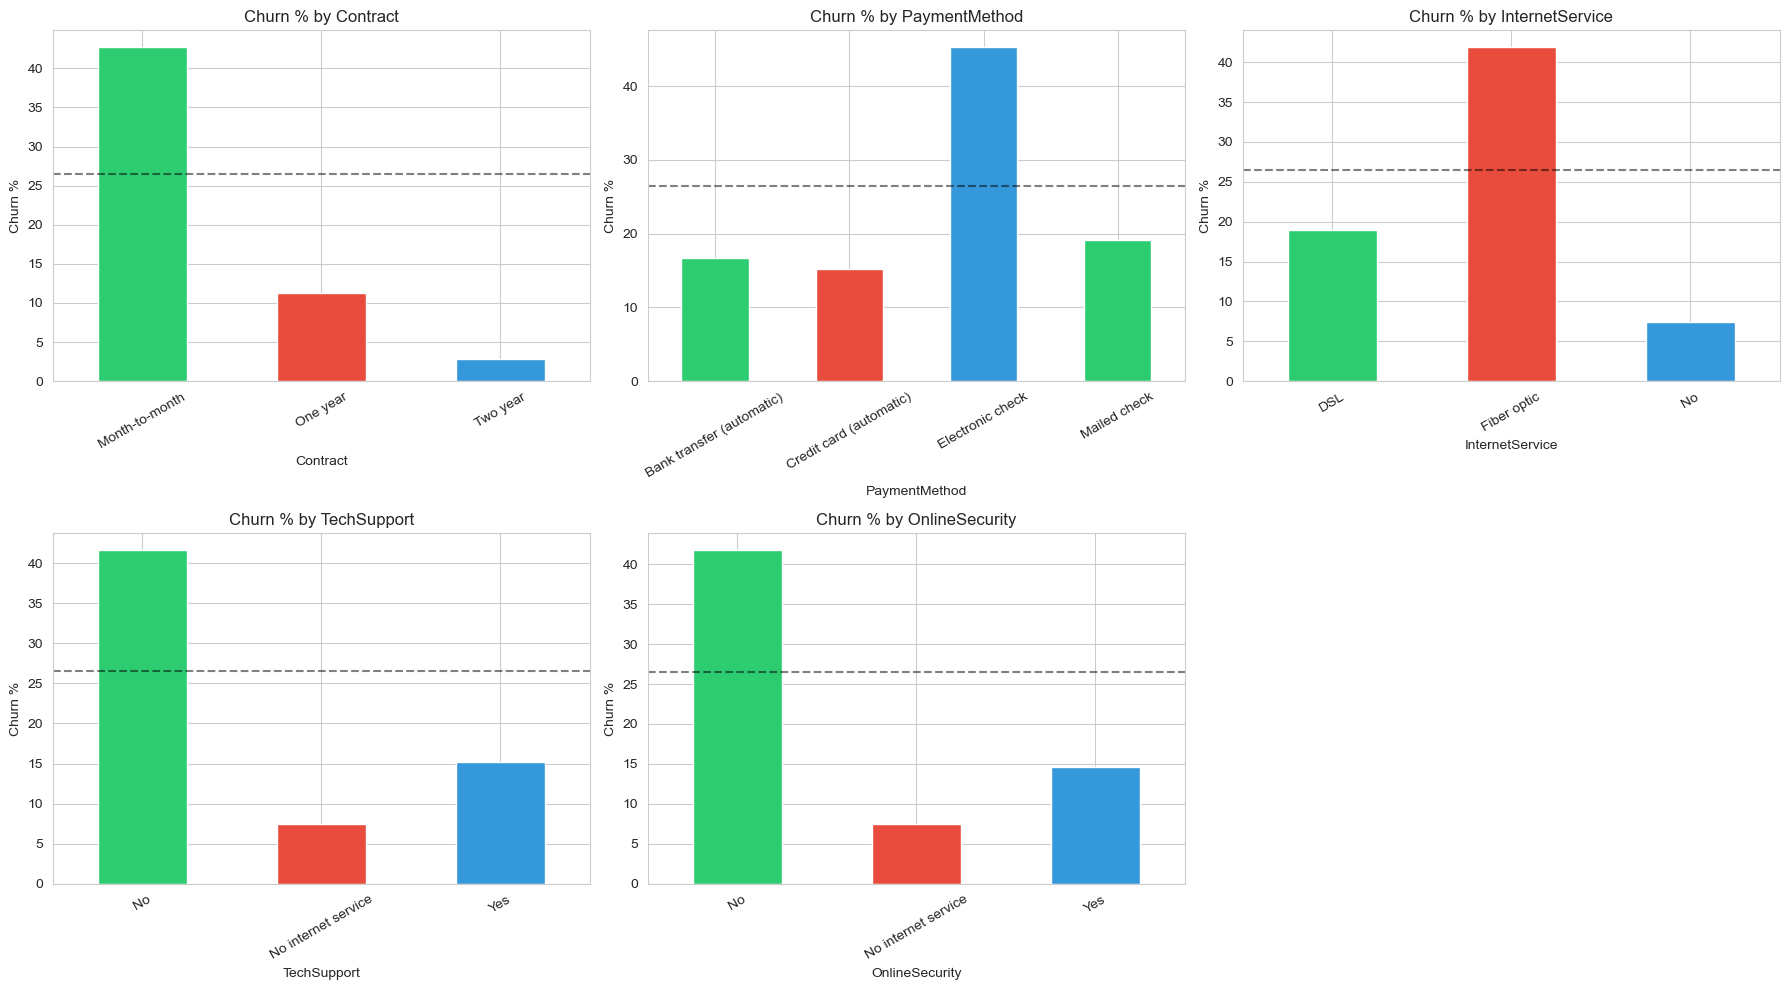

In [11]:
# ============================================
# CELL 6: Key categorical churn drivers
# ============================================
cat_cols = ['Contract', 'PaymentMethod', 'InternetService',
            'TechSupport', 'OnlineSecurity']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    rate = df.groupby(col)['Churn'].apply(lambda x: (x == 'Yes').mean() * 100)
    rate.plot(kind='bar', ax=axes[i], color=['#2ecc71', '#e74c3c', '#3498db'])
    axes[i].set_title(f'Churn % by {col}')
    axes[i].set_ylabel('Churn %')
    axes[i].axhline(26.5, color='black', ls='--', alpha=0.5)
    axes[i].tick_params(axis='x', rotation=30)

fig.delaxes(axes[5])
plt.tight_layout()
plt.savefig('C:/churn-project/images/categorical_drivers.png', dpi=150)
plt.show()


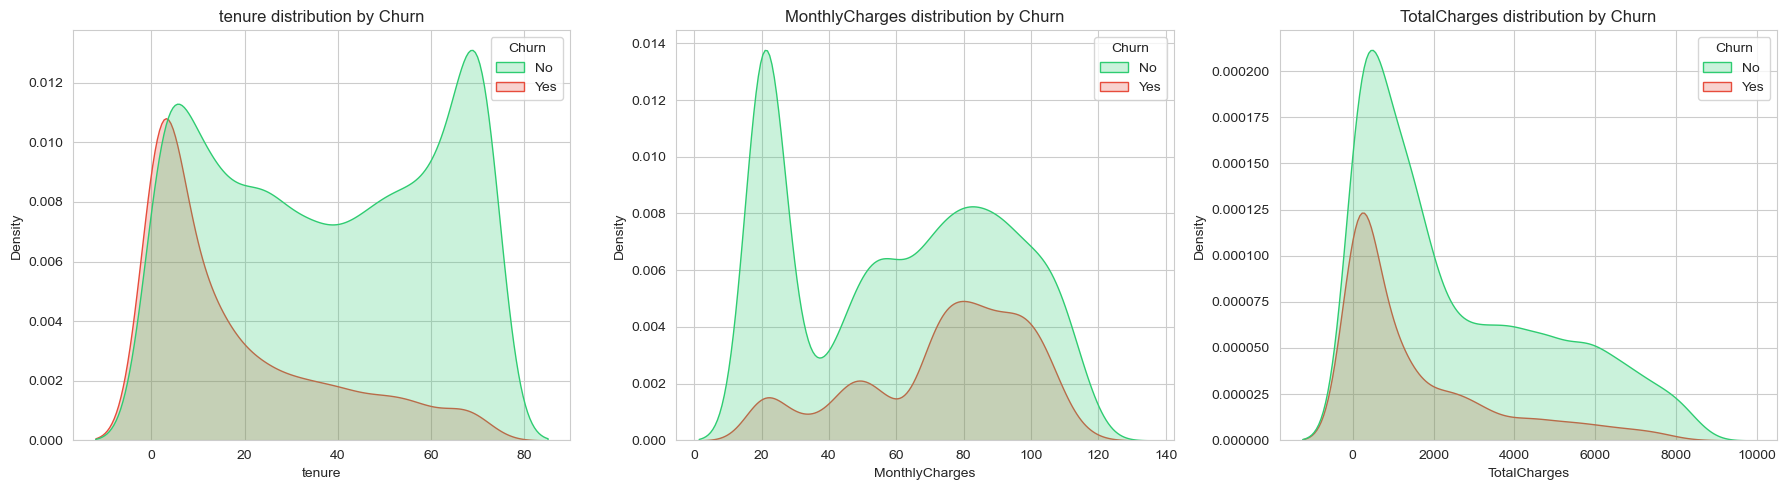

In [12]:
# ============================================
# CELL 7: Numeric feature distributions by churn
# ============================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, col in enumerate(['tenure', 'MonthlyCharges', 'TotalCharges']):
    sns.kdeplot(data=df, x=col, hue='Churn', fill=True, ax=axes[i],
                palette={'Yes': '#e74c3c', 'No': '#2ecc71'})
    axes[i].set_title(f'{col} distribution by Churn')

plt.tight_layout()
plt.savefig('C:/churn-project/images/numeric_distributions.png', dpi=150)
plt.show()


C:\Users\hp\AppData\Local\Temp\ipykernel_21516\1494142916.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  rate = df.groupby('tenure_group')['Churn'].apply(lambda x: (x == 'Yes').mean() * 100)


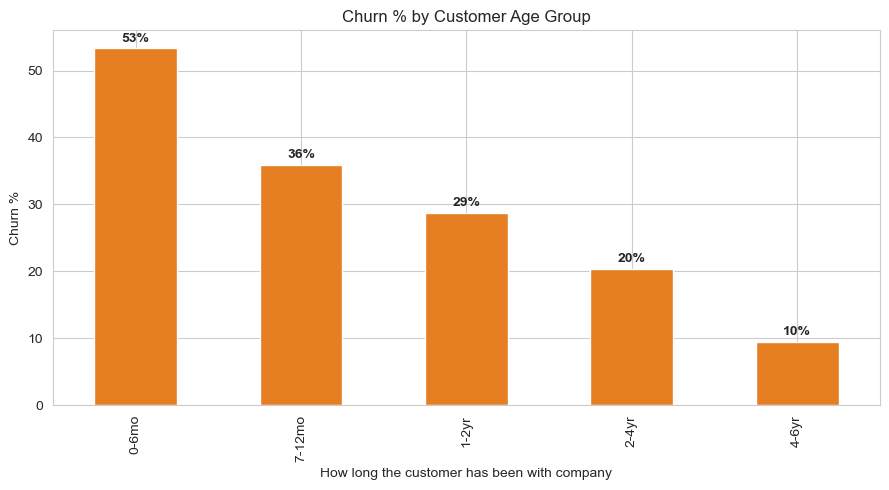

In [13]:
# ============================================
# CELL 8: Churn % by customer age group
# ============================================
bins = [0, 6, 12, 24, 48, 72]
labels = ['0-6mo', '7-12mo', '1-2yr', '2-4yr', '4-6yr']
df['tenure_group'] = pd.cut(df['tenure'], bins=bins, labels=labels)

rate = df.groupby('tenure_group')['Churn'].apply(lambda x: (x == 'Yes').mean() * 100)

ax = rate.plot(kind='bar', color='#e67e22', figsize=(9, 5),
               title='Churn % by Customer Age Group')
ax.set_ylabel('Churn %')
ax.set_xlabel('How long the customer has been with company')

# Add value labels on top of bars
for i, v in enumerate(rate):
    ax.text(i, v + 1, f'{v:.0f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('C:/churn-project/images/tenure_group_churn.png', dpi=150)
plt.show()


In [14]:
# ============================================
# CELL 9: Preprocessing — encode all columns
# ============================================

# Start fresh copy; drop helper column
model_df = df.drop('tenure_group', axis=1).copy()

# ---- 1. Binary Yes/No columns → 1/0 ----
binary_cols = ['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling',
               'MultipleLines', 'OnlineSecurity', 'OnlineBackup',
               'DeviceProtection', 'TechSupport', 'StreamingTV',
               'StreamingMovies']

for col in binary_cols:
    model_df[col] = model_df[col].replace({'Yes': 1, 'No': 0,
                                           'No internet service': 0,
                                           'No phone service': 0})

# ---- 2. Gender → 1/0 ----
model_df['gender'] = model_df['gender'].map({'Male': 1, 'Female': 0})

# ---- 3. InternetService (ordinal) ----
model_df['InternetService'] = model_df['InternetService'].map(
    {'No': 0, 'DSL': 1, 'Fiber optic': 2})

# ---- 4. Contract (ordinal: strongest retention = highest number) ----
model_df['Contract'] = model_df['Contract'].map(
    {'Month-to-month': 0, 'One year': 1, 'Two year': 2})

# ---- 5. PaymentMethod → one-hot encoding ----
model_df = pd.get_dummies(model_df, columns=['PaymentMethod'], drop_first=True)

# ---- 6. Target variable ----
model_df['Churn'] = model_df['Churn'].map({'Yes': 1, 'No': 0})

print("Encoded shape:", model_df.shape)
model_df.head()


Encoded shape: (7032, 22)


C:\Users\hp\AppData\Local\Temp\ipykernel_21516\675117781.py:15: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  model_df[col] = model_df[col].replace({'Yes': 1, 'No': 0,


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,1,0,0,1,0,1,0,0,0,0,0,1,29.85,29.85,0,False,True,False
1,1,0,0,0,34,1,0,1,1,0,1,0,0,0,1,0,56.95,1889.50,0,False,False,True
2,1,0,0,0,2,1,0,1,1,1,0,0,0,0,0,1,53.85,108.15,1,False,False,True
3,1,0,0,0,45,0,0,1,1,0,1,1,0,0,1,0,42.30,1840.75,0,False,False,False
4,0,0,0,0,2,1,0,2,0,0,0,0,0,0,0,1,70.70,151.65,1,False,True,False


In [16]:
# ============================================
# CELL 10: Train/Test split
# ============================================
from sklearn.model_selection import train_test_split

X = model_df.drop('Churn', axis=1)   # features (everything except target)
y = model_df['Churn']                # target (0 = stayed, 1 = churned)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,        # 20% held out for testing
    random_state=42,      # reproducibility — same split every run
    stratify=y            # keep same churn % in train AND test
)

print(f"Train set: {X_train.shape} | Churn rate: {y_train.mean():.1%}")
print(f"Test set : {X_test.shape} | Churn rate: {y_test.mean():.1%}")


Train set: (5625, 21) | Churn rate: 26.6%
Test set : (1407, 21) | Churn rate: 26.6%


In [17]:
# ============================================
# CELL 11: Standardize numeric features
# ============================================
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols]  = scaler.transform(X_test[num_cols])   # ⚠️ transform ONLY

print("Train scaled (head):")
X_train[num_cols].head()


Train scaled (head):


,tenure,MonthlyCharges,TotalCharges
1408,1.321816,0.981556,1.659900
6992,-0.267410,-0.971546,-0.562252
3349,1.444064,0.837066,1.756104
4486,-1.204646,0.641092,-0.908326
3535,0.669826,-0.808787,-0.101561


In [18]:
# ============================================
# CELL 12: SMOTE oversampling
# ============================================
from imblearn.over_sampling import SMOTE

print("BEFORE SMOTE:")
print(y_train.value_counts().to_dict())

smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

print("\nAFTER SMOTE:")
print(y_train_bal.value_counts().to_dict())
print(f"\nNew balanced training size: {X_train_bal.shape}")


BEFORE SMOTE:
{0: 4130, 1: 1495}

AFTER SMOTE:
{0: 4130, 1: 4130}

New balanced training size: (8260, 21)


In [19]:
# ============================================
# CELL 13: Baseline — Logistic Regression
# ============================================
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_bal, y_train_bal)

# Predictions
y_pred_lr = lr.predict(X_test)                 # class prediction (0/1)
y_prob_lr = lr.predict_proba(X_test)[:, 1]     # probability of churn (0-1)

print(classification_report(y_test, y_pred_lr,
      target_names=['Stayed (0)', 'Churned (1)']))
print("ROC-AUC:", round(roc_auc_score(y_test, y_prob_lr), 4))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_lr))


              precision    recall  f1-score   support

  Stayed (0)       0.89      0.75      0.81      1033
 Churned (1)       0.52      0.74      0.61       374

    accuracy                           0.75      1407
   macro avg       0.70      0.75      0.71      1407
weighted avg       0.79      0.75      0.76      1407

ROC-AUC: 0.8219

Confusion Matrix:
[[774 259]
 [ 96 278]]


In [20]:
# ============================================
# CELL 14: XGBoost + GridSearchCV tuning
# ============================================
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV

xgb = XGBClassifier(random_state=42, eval_metric='logloss')

params = {
    'n_estimators': [100, 200],       # number of trees
    'max_depth': [3, 4, 5],           # tree depth (deeper = more complex)
    'learning_rate': [0.05, 0.1]      # how fast model learns
}

grid = GridSearchCV(
    xgb, params,
    cv=5,                # 5-fold cross-validation
    scoring='roc_auc',   # optimize for AUC
    n_jobs=-1            # use all CPU cores
)
grid.fit(X_train_bal, y_train_bal)

best_xgb = grid.best_estimator_

# Evaluate on unseen test set
y_pred = best_xgb.predict(X_test)
y_prob = best_xgb.predict_proba(X_test)[:, 1]

from sklearn.metrics import classification_report, roc_auc_score
print("Best parameters found:", grid.best_params_)
print("\n", classification_report(y_test, y_pred,
      target_names=['Stayed (0)', 'Churned (1)']))
print("ROC-AUC:", round(roc_auc_score(y_test, y_prob), 4))


Best parameters found: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200}

               precision    recall  f1-score   support

  Stayed (0)       0.87      0.78      0.82      1033
 Churned (1)       0.53      0.66      0.59       374

    accuracy                           0.75      1407
   macro avg       0.70      0.72      0.70      1407
weighted avg       0.77      0.75      0.76      1407

ROC-AUC: 0.816


In [21]:
# ============================================
# CELL 15: ROC Curve — both models together
# ============================================
from sklearn.metrics import roc_curve, roc_auc_score

# Calculate points for both models
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_prob)

auc_lr = roc_auc_score(y_test, y_prob_lr)
auc_xgb = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(9, 7))
plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC = {auc_lr:.3f})',
         color='#3498db', linewidth=2)
plt.plot(fpr_xgb, tpr_xgb, label=f'XGBoost (AUC = {auc_xgb:.3f})',
         color='#e74c3c', linewidth=2)
plt.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Random guessing (AUC = 0.5)')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('Model Comparison — ROC


SyntaxError: unterminated string literal (detected at line 22) (4150310148.py, line 22)

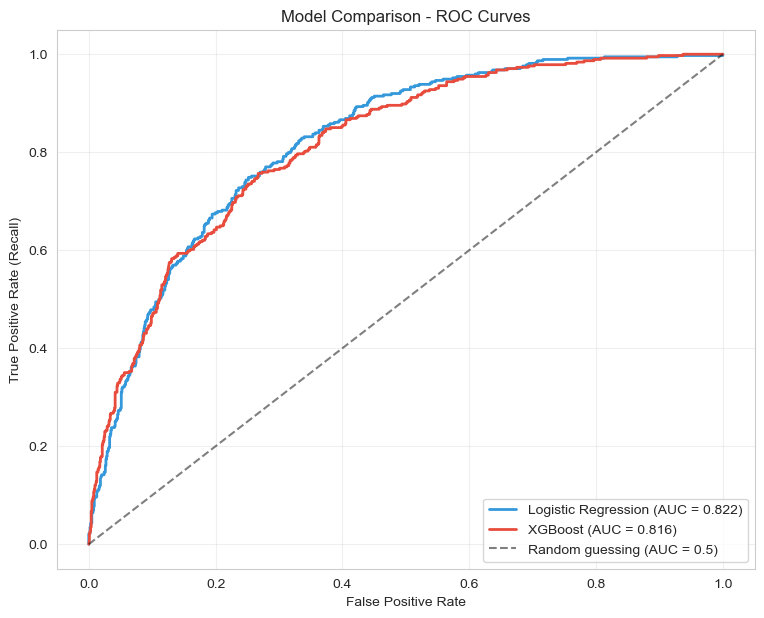

In [22]:
# ============================================
# CELL 15: ROC Curve - both models together
# ============================================
from sklearn.metrics import roc_curve, roc_auc_score

# Calculate points for both models
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_prob)

auc_lr = roc_auc_score(y_test, y_prob_lr)
auc_xgb = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(9, 7))
plt.plot(fpr_lr, tpr_lr,
         label=f'Logistic Regression (AUC = {auc_lr:.3f})',
         color='#3498db', linewidth=2)
plt.plot(fpr_xgb, tpr_xgb,
         label=f'XGBoost (AUC = {auc_xgb:.3f})',
         color='#e74c3c', linewidth=2)
plt.plot([0, 1], [0, 1], 'k--', alpha=0.5,
         label='Random guessing (AUC = 0.5)')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('Model Comparison - ROC Curves')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.savefig('C:/churn-project/images/roc_comparison.png', dpi=150)
plt.show()


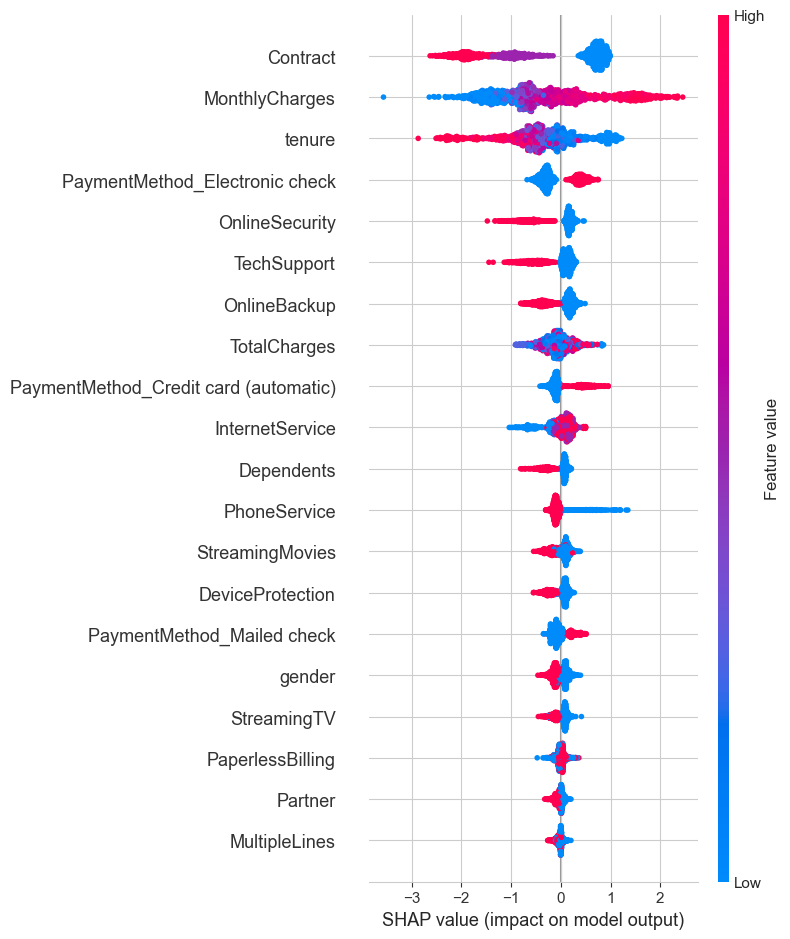

In [23]:
# ============================================
# CELL 16: SHAP explainability
# ============================================
import shap

explainer = shap.TreeExplainer(best_xgb)
shap_values = explainer.shap_values(X_test)

# Summary plot (beeswarm)
shap.summary_plot(shap_values, X_test, show=False)
plt.savefig('C:/churn-project/images/shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()


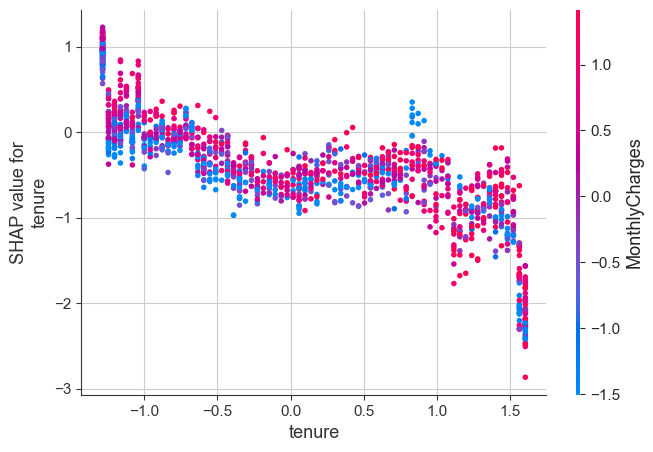

In [24]:
# ============================================
# CELL 17: SHAP dependence plots
# ============================================
# Plot 1: How tenure affects churn
shap.dependence_plot('tenure', shap_values, X_test, show=False)
plt.savefig('C:/churn-project/images/shap_tenure.png', dpi=150, bbox_inches='tight')
plt.show()


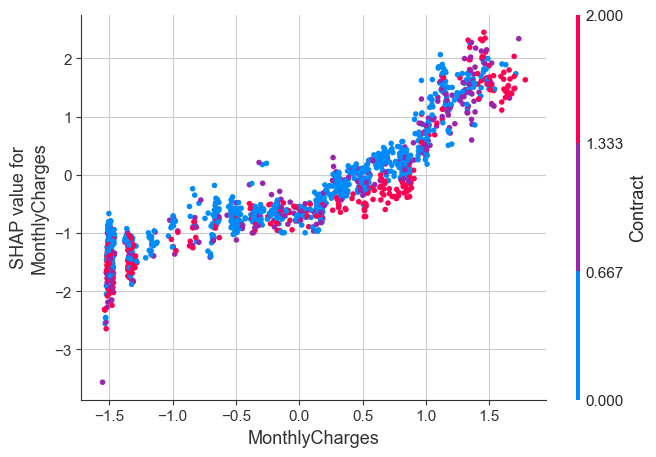

In [25]:
# Plot 2: Monthly charges effect
shap.dependence_plot('MonthlyCharges', shap_values, X_test, show=False)
plt.savefig('C:/churn-project/images/shap_charges.png', dpi=150, bbox_inches='tight')
plt.show()


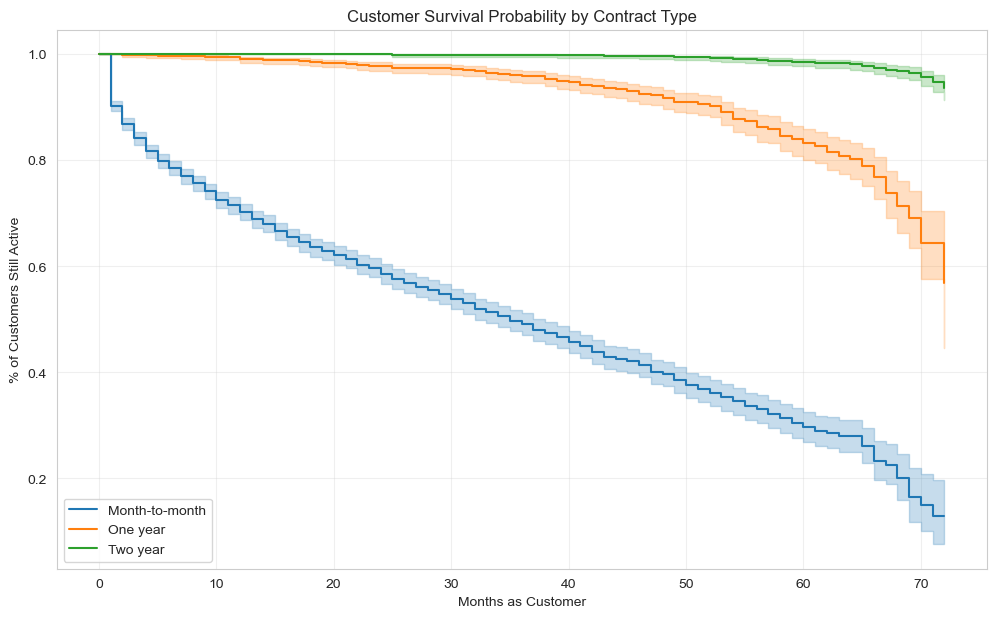

In [26]:

# ============================================
# CELL 18: Kaplan-Meier survival curves by contract
# ============================================
from lifelines import KaplanMeierFitter

kmf = KaplanMeierFitter()
plt.figure(figsize=(12, 7))

for name, group in df.groupby('Contract'):
    kmf.fit(group['tenure'],
            event_observed=(group['Churn'] == 'Yes'),
            label=name)
    kmf.plot_survival_function()

plt.title('Customer Survival Probability by Contract Type')
plt.xlabel('Months as Customer')
plt.ylabel('% of Customers Still Active')
plt.grid(alpha=0.3)
plt.savefig('C:/churn-project/images/survival_curves.png', dpi=150)
plt.show()


In [27]:
# ============================================
# CELL 19: Median survival time per contract type
# ============================================
print("Median customer lifetime by contract type:\n")

for name, group in df.groupby('Contract'):
    kmf.fit(group['tenure'],
            event_observed=(group['Churn'] == 'Yes'))
    mst = kmf.median_survival_time_
    print(f"{name:15} : {mst:.0f} months")


Median customer lifetime by contract type:

Month-to-month  : 35 months
One year        : inf months
Two year        : inf months


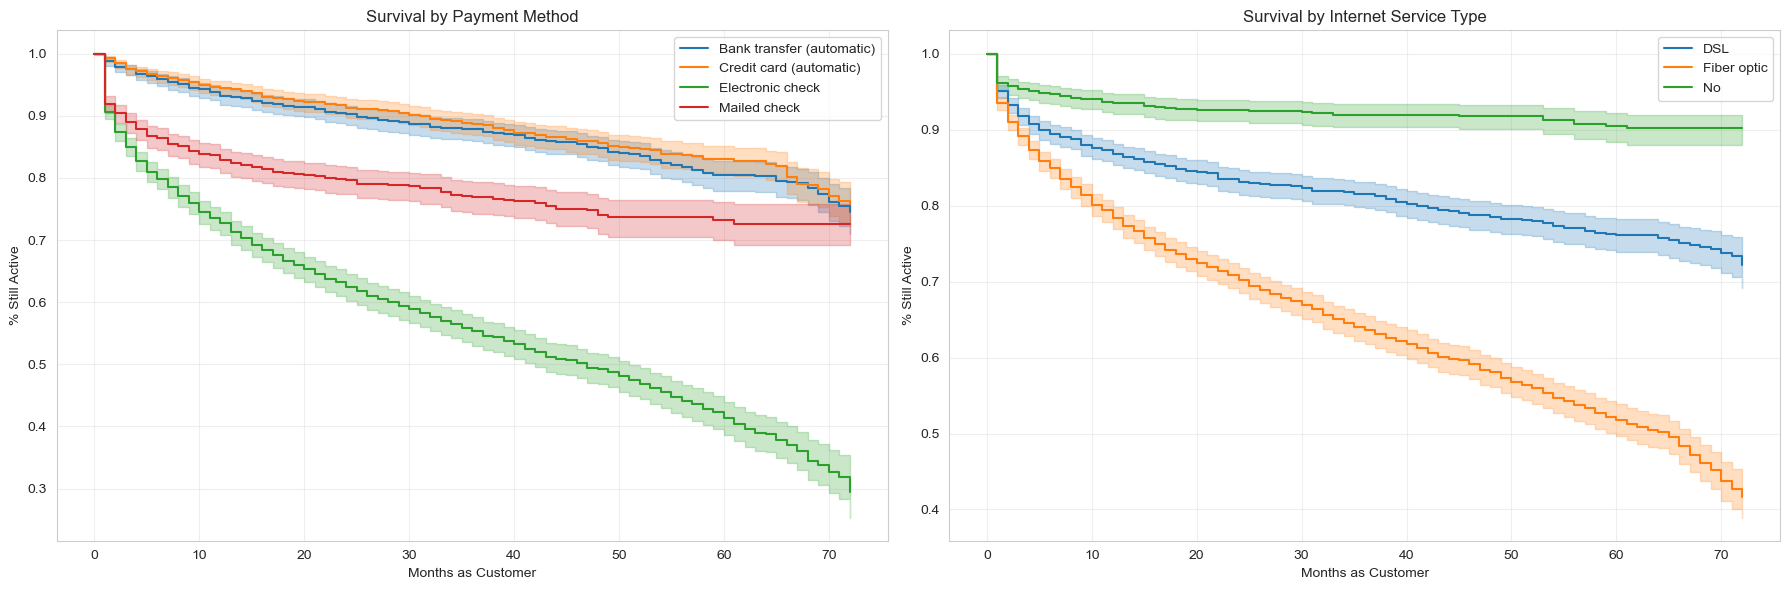

In [28]:
# ============================================
# CELL 20: Survival curves - two more segment views
# ============================================
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# --- Left chart: Payment Method ---
for name, group in df.groupby('PaymentMethod'):
    kmf.fit(group['tenure'],
            event_observed=(group['Churn'] == 'Yes'), label=name)
    kmf.plot_survival_function(ax=axes[0])

axes[0].set_title('Survival by Payment Method')
axes[0].set_xlabel('Months as Customer')
axes[0].set_ylabel('% Still Active')
axes[0].grid(alpha=0.3)

# --- Right chart: Internet Service ---
for name, group in df.groupby('InternetService'):
    kmf.fit(group['tenure'],
            event_observed=(group['Churn'] == 'Yes'), label=name)
    kmf.plot_survival_function(ax=axes[1])

axes[1].set_title('Survival by Internet Service Type')
axes[1].set_xlabel('Months as Customer')
axes[1].set_ylabel('% Still Active')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('C:/churn-project/images/survival_segments.png', dpi=150)
plt.show()


In [42]:
# ============================================
# CELL 21: Risk-scored customer list
# ============================================

# Attach predictions to test customers
risk_df = X_test.copy()
risk_df['churn_probability'] = y_prob

# Tier customers by risk
risk_df['risk_tier'] = pd.cut(
    risk_df['churn_probability'],
    bins=[0, 0.4, 0.7, 1.0],
    labels=['Low', 'Medium', 'High']
)

print("Risk tier distribution:")
print(risk_df['risk_tier'].value_counts())

# High-risk list sorted by probability
high_risk = risk_df[risk_df['risk_tier'] == 'High'].sort_values(
    by='churn_probability', ascending=False)

print(f"\nHigh-risk customers flagged: {len(high_risk)}")
high_risk[['churn_probability', 'risk_tier']].head(10)


Risk tier distribution:
risk_tier
Low       834
High      308
Medium    265
Name: count, dtype: int64

High-risk customers flagged: 308


,churn_probability,risk_tier
2922,0.978877,High
1734,0.978877,High
807,0.977822,High
3676,0.977353,High
2626,0.976462,High
1726,0.974917,High
2602,0.974908,High
3721,0.971831,High
2459,0.970824,High
6545,0.970385,High


In [40]:
# ============================================
# CELL 22: Revenue protection estimate
# ============================================

avg_lifetime_value = df[df['Churn'] == 'No']['TotalCharges'].mean()
n_high = len(high_risk)

print(f"Average lifetime value of a retained customer : {avg_lifetime_value:,.0f}")
print(f"High-risk customers identified               : {n_high}")

saved_30pct = int(n_high * 0.30)
revenue_protected = saved_30pct * avg_lifetime_value

print(f"\nIf a targeted campaign saves 30% of them ({saved_30pct} customers):")
print(f"Revenue protected = {revenue_protected:,.0f}")


Average lifetime value of a retained customer : 2,555
High-risk customers identified               : 311

If a targeted campaign saves 30% of them (93 customers):
Revenue protected = 237,647


In [32]:
# ============================================
# CELL 23: Save deliverable CSV
# ============================================
high_risk.to_csv('C:/churn-project/high_risk_customers.csv')
print("Saved: high_risk_customers.csv -", len(high_risk), "customers")


Saved: high_risk_customers.csv - 311 customers


In [33]:
# ============================================
# CELL 24: Save model & preprocessing objects
# ============================================
import joblib
import pickle

joblib.dump(best_xgb, 'C:/churn-project/app/xgb_model.joblib')

with open('C:/churn-project/app/scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

with open('C:/churn-project/app/feature_names.pkl', 'wb') as f:
    pickle.dump(list(X.columns), f)

print("Saved 3 files to app folder:")
print("- xgb_model.joblib   (trained model)")
print("- scaler.pkl         (feature scaler)")
print("- feature_names.pkl  (column order)")


Saved 3 files to app folder:
- xgb_model.joblib   (trained model)
- scaler.pkl         (feature scaler)
- feature_names.pkl  (column order)


In [35]:
# CELL 14b: Wider XGBoost tuning
params2 = {
    'n_estimators': [300, 500],
    'max_depth': [3, 4],
    'learning_rate': [0.03, 0.05],
    'subsample': [0.8],
    'colsample_bytree': [0.8]
}
grid2 = GridSearchCV(XGBClassifier(random_state=42, eval_metric='logloss'),
                     params2, cv=5, scoring='roc_auc', n_jobs=-1)
grid2.fit(X_train_bal, y_train_bal)
best_xgb = grid2.best_estimator_
y_prob = best_xgb.predict_proba(X_test)[:, 1]
print("Best:", grid2.best_params_)
print("ROC-AUC:", round(roc_auc_score(y_test, y_prob), 4))


Best: {'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 4, 'n_estimators': 500, 'subsample': 0.8}
ROC-AUC: 0.8185


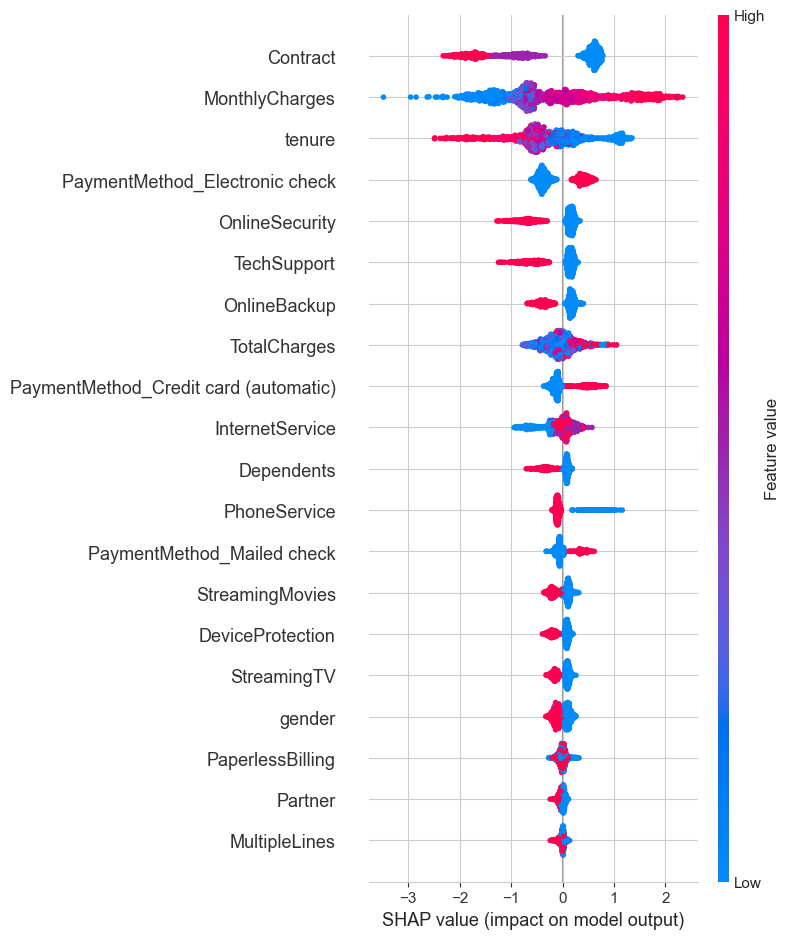

In [36]:
# ============================================
# CELL 16: SHAP explainability
# ============================================
import shap

explainer = shap.TreeExplainer(best_xgb)
shap_values = explainer.shap_values(X_test)

# Summary plot (beeswarm)
shap.summary_plot(shap_values, X_test, show=False)
plt.savefig('C:/churn-project/images/shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()


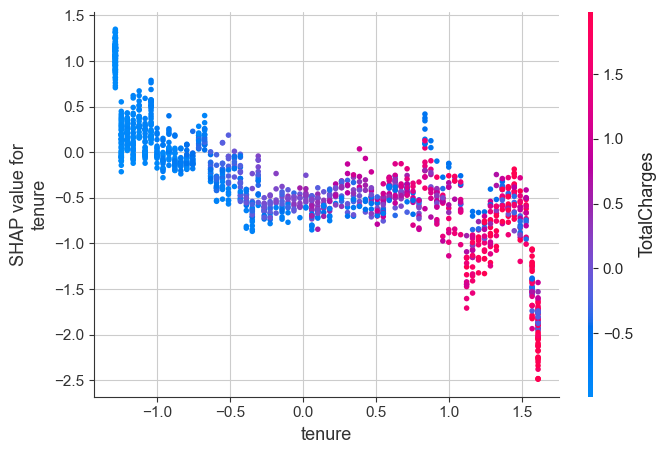

In [37]:
# ============================================
# CELL 17: SHAP dependence plots
# ============================================
# Plot 1: How tenure affects churn
shap.dependence_plot('tenure', shap_values, X_test, show=False)
plt.savefig('C:/churn-project/images/shap_tenure.png', dpi=150, bbox_inches='tight')
plt.show()


In [38]:
# ============================================
# CELL 24: Save model & preprocessing objects
# ============================================
import joblib
import pickle

joblib.dump(best_xgb, 'C:/churn-project/app/xgb_model.joblib')

with open('C:/churn-project/app/scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

with open('C:/churn-project/app/feature_names.pkl', 'wb') as f:
    pickle.dump(list(X.columns), f)

print("Saved 3 files to app folder:")
print("- xgb_model.joblib   (trained model)")
print("- scaler.pkl         (feature scaler)")
print("- feature_names.pkl  (column order)")



Saved 3 files to app folder:
- xgb_model.joblib   (trained model)
- scaler.pkl         (feature scaler)
- feature_names.pkl  (column order)
